In [1]:
import os
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Set the image directory path
image_dir = '/Users/shubhbhateja/College/minor_project/images' 

# Get all image file paths
image_paths = glob.glob(os.path.join(image_dir, '*.jpg')) 

# Load images into a list
images = []
for path in image_paths:
    img = cv2.imread(path)
    if img is not None:
        images.append(img)

print(f"Loaded {len(images)} images.")

Loaded 2235 images.


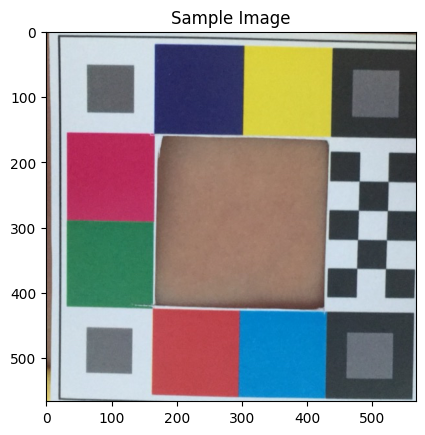

In [3]:
# Display the first image
if images:
    plt.imshow(cv2.cvtColor(images[1032], cv2.COLOR_BGR2RGB))
    # plt.axis('off')
    plt.title('Sample Image')
    plt.show()
else:
    print('No images loaded.')

# Color Calibration using HSV Card Detection

## Step-by-step Process:

### 1. Convert RGB to HSV
- Transform the image from RGB color space to HSV
- HSV separates color information (Hue) from lighting (Value)

### 2. Define Color Ranges for Card Detection
- Set HSV ranges for specific colors on the reference card
- Common colors: White, Gray, Red, Blue, Green patches

### 3. Create Color Masks
- Use `cv2.inRange()` to create binary masks for each color
- Mask identifies pixels belonging to each reference color

### 4. Detect Card Regions
- Find contours of masked regions
- Filter by area/shape to identify actual card patches

### 5. Extract Reference Colors
- Calculate mean color values from detected card regions
- Compare with known reference values

### 6. Calculate Color Correction Matrix
- Compute transformation needed to match reference colors
- Apply correction to entire image

### 7. Apply Calibration
- Transform all pixel colors using the correction matrix

In [4]:
# Step 1: Convert RGB to HSV
def convert_to_hsv(image):
    """Convert BGR image to HSV color space"""
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    return hsv_image

# Test with sample image
sample_image = images[0]
hsv_sample = convert_to_hsv(sample_image)

print(f"Original shape: {sample_image.shape}")
print(f"HSV shape: {hsv_sample.shape}")
print(f"HSV range: H(0-179), S(0-255), V(0-255)")

Original shape: (567, 567, 3)
HSV shape: (567, 567, 3)
HSV range: H(0-179), S(0-255), V(0-255)


In [5]:
# Step 2: Define HSV Color Ranges for Reference Card
def define_color_ranges():
    """Define HSV ranges for common reference card colors"""
    color_ranges = {
        'white': {
            'lower': np.array([0, 0, 200]),    # Low saturation, high value
            'upper': np.array([180, 30, 255])
        },
        'gray': {
            'lower': np.array([0, 0, 100]),    # Low saturation, medium value
            'upper': np.array([180, 30, 200])
        },
        'red': {
            'lower': np.array([0, 120, 100]),   # Red hue range
            'upper': np.array([10, 255, 255])
        },
        'blue': {
            'lower': np.array([100, 120, 100]), # Blue hue range
            'upper': np.array([130, 255, 255])
        }
    }
    return color_ranges

# Get color ranges
card_colors = define_color_ranges()
print("Defined color ranges for:", list(card_colors.keys()))

Defined color ranges for: ['white', 'gray', 'red', 'blue']


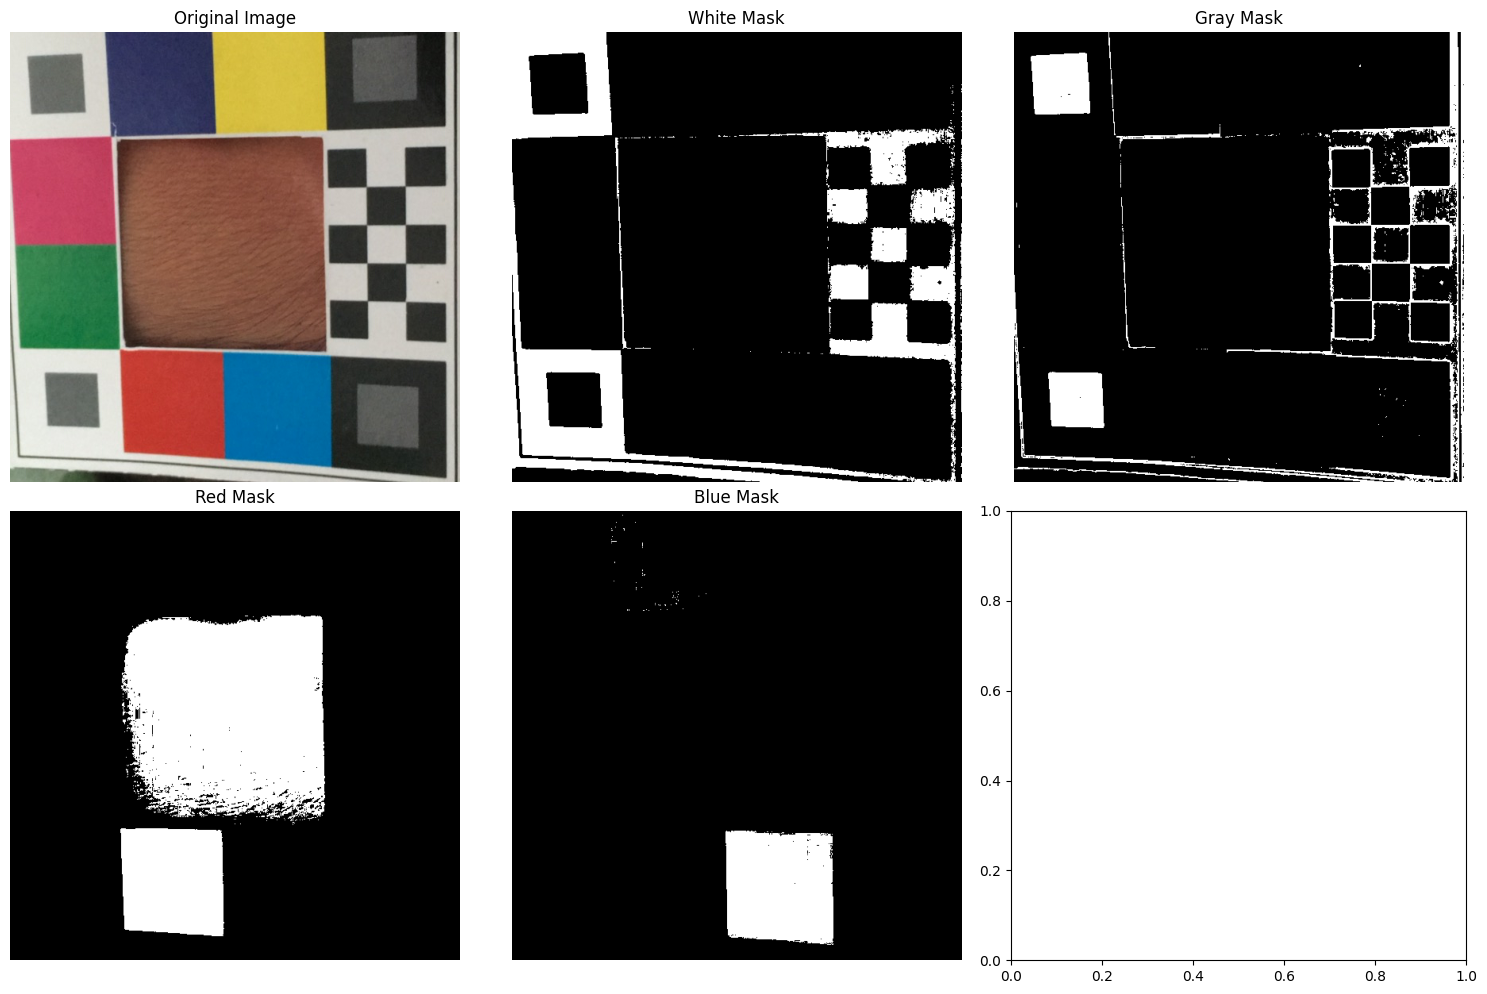

In [6]:
# Step 3: Create Color Masks
def create_color_masks(hsv_image, color_ranges):
    """Create binary masks for each reference color"""
    masks = {}
    
    for color_name, range_values in color_ranges.items():
        # Create mask using cv2.inRange
        mask = cv2.inRange(hsv_image, range_values['lower'], range_values['upper'])
        masks[color_name] = mask
    
    return masks

# Test mask creation
hsv_test = convert_to_hsv(images[0])
color_masks = create_color_masks(hsv_test, card_colors)

# Display masks for visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Original image
axes[0].imshow(cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')

# Show masks
for i, (color_name, mask) in enumerate(color_masks.items(), 1):
    axes[i].imshow(mask, cmap='gray')
    axes[i].set_title(f'{color_name.title()} Mask')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

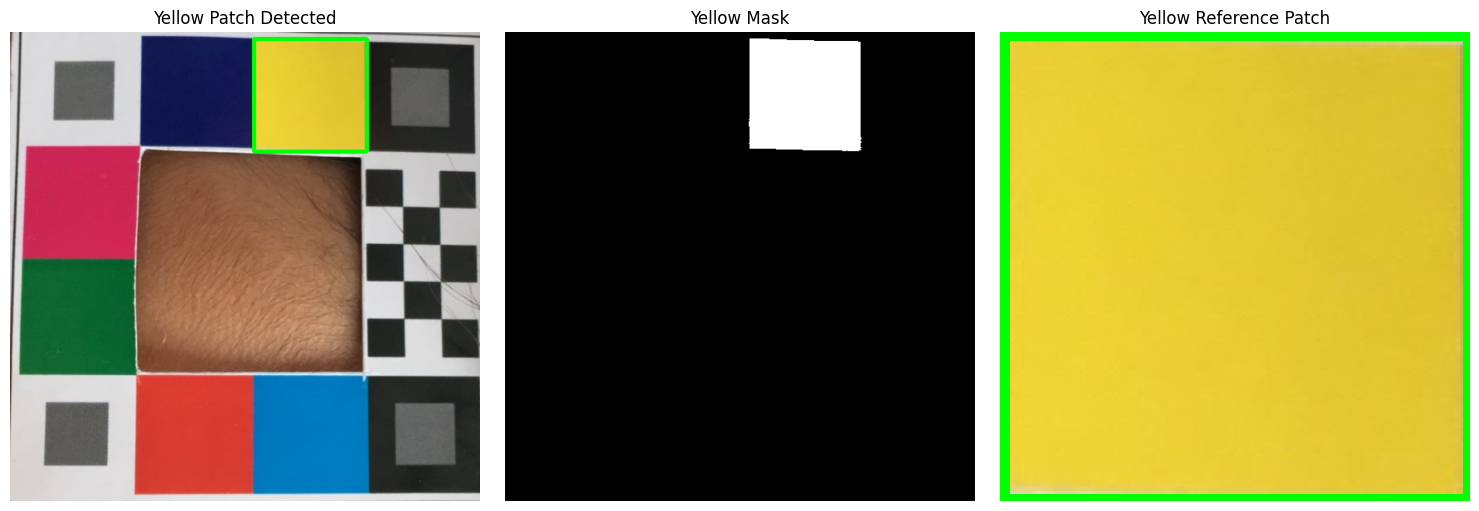

Yellow patch mean BGR: [ 54.84883218 200.45231401 226.77449178]


In [7]:
# Step 4: Detect Yellow Reference Patch (Simplified for Standardized Images)
def detect_yellow_patch(image):
    """Detect yellow reference patch using HSV color space"""
    # Convert to HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Define yellow color range in HSV
    yellow_lower = np.array([20, 100, 100])   # Lower yellow threshold
    yellow_upper = np.array([30, 255, 255])   # Upper yellow threshold
    
    # Create yellow mask
    yellow_mask = cv2.inRange(hsv, yellow_lower, yellow_upper)
    
    # Find contours in the mask
    contours, _ = cv2.findContours(yellow_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Find the largest yellow region (should be the reference patch)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest_contour)
        
        if area > 1000:  # Minimum area for yellow patch
            # Get bounding rectangle
            x, y, w, h = cv2.boundingRect(largest_contour)
            yellow_patch = image[y:y+h, x:x+w]
            
            # Calculate mean color of yellow patch
            mean_bgr = np.mean(yellow_patch.reshape(-1, 3), axis=0)
            
            return {
                'patch': yellow_patch,
                'mean_bgr': mean_bgr,
                'bbox': (x, y, w, h),
                'mask': yellow_mask
            }
    
    return None

# Test yellow patch detection
sample_img = images[10].copy()
yellow_info = detect_yellow_patch(sample_img)

if yellow_info:
    # Draw bounding box around yellow patch
    x, y, w, h = yellow_info['bbox']
    cv2.rectangle(sample_img, (x, y), (x+w, y+h), (0, 255, 0), 3)
    
    # Display results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original with yellow patch highlighted
    axes[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Yellow Patch Detected')
    axes[0].axis('off')
    
    # Yellow mask
    axes[1].imshow(yellow_info['mask'], cmap='gray')
    axes[1].set_title('Yellow Mask')
    axes[1].axis('off')
    
    # Extracted yellow patch
    axes[2].imshow(cv2.cvtColor(yellow_info['patch'], cv2.COLOR_BGR2RGB))
    axes[2].set_title('Yellow Reference Patch')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Yellow patch mean BGR: {yellow_info['mean_bgr']}")
else:
    print("Yellow patch not detected")

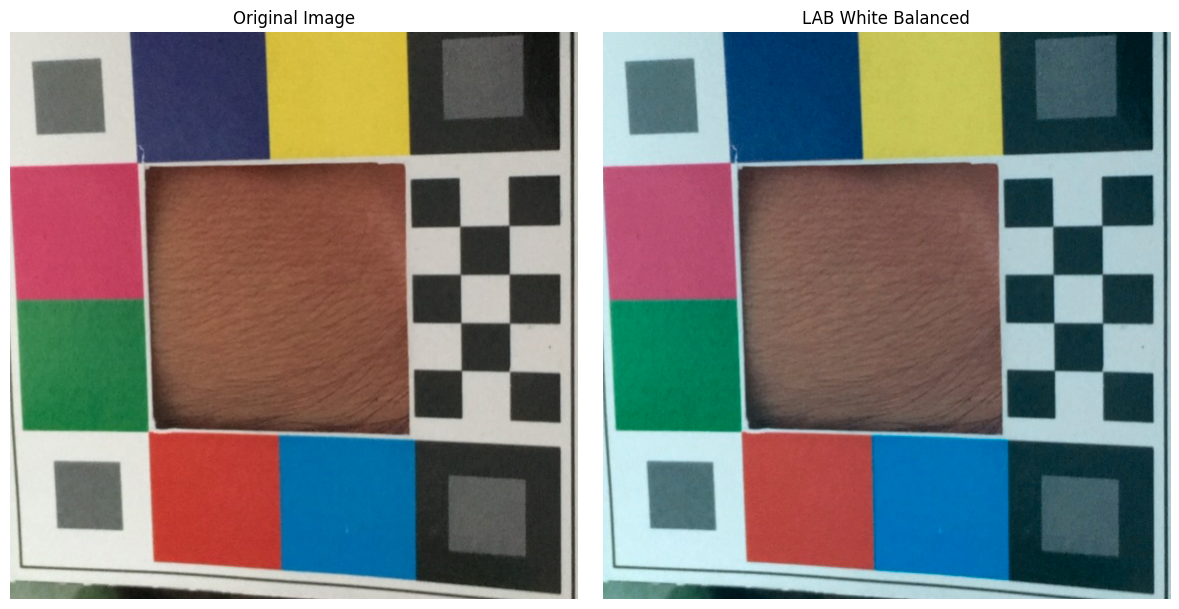

White balancing completed using yellow reference patch


In [8]:
# Step 5: LAB White Balancing using Yellow Reference
def lab_white_balance_with_reference(image, reference_bgr):
    """Perform LAB white balancing using yellow patch as reference"""
    
    # Convert image to LAB
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    # Convert reference BGR to LAB
    ref_lab = cv2.cvtColor(np.uint8([[reference_bgr]]), cv2.COLOR_BGR2LAB)[0][0]
    ref_l, ref_a, ref_b = ref_lab
    
    # Calculate image mean a and b
    avg_a = np.mean(a)
    avg_b = np.mean(b)
    
    # Target values (neutral should be around 128 for a and b channels)
    target_a = 128
    target_b = 128
    
    # Calculate correction factors
    correction_a = target_a - avg_a
    correction_b = target_b - avg_b
    
    # Apply corrections
    a_corrected = np.clip(a + correction_a, 0, 255)
    b_corrected = np.clip(b + correction_b, 0, 255)
    
    # Merge corrected channels
    lab_corrected = cv2.merge([l, a_corrected.astype(np.uint8), b_corrected.astype(np.uint8)])
    
    # Convert back to BGR
    balanced = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)
    
    return balanced

# Test white balancing if yellow patch detected
if yellow_info:
    # Apply white balancing
    balanced_image = lab_white_balance_with_reference(images[0], yellow_info['mean_bgr'])
    
    # Display comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Original image
    axes[0].imshow(cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # White balanced image
    axes[1].imshow(cv2.cvtColor(balanced_image, cv2.COLOR_BGR2RGB))
    axes[1].set_title('LAB White Balanced')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("White balancing completed using yellow reference patch")
else:
    print("Cannot perform white balancing - no yellow reference found")